# AudioMind: Build a pyannote-Powered Conversation Intelligence Demo

This notebook shows how AudioMind uses pyannote to turn raw conversation audio into something developers can build on: a reliable speaker timeline.

A plain transcript tells you what was said, but it loses one of the most important parts of a community call: **who said it and when**. pyannote adds that missing structure. Once AudioMind knows the speaker turns, it can attach transcript text, identify known voices, and ask an LLM to extract follow-up work.

**Audience:** developers building AI workflow demos, DevRel tooling, meeting intelligence prototypes, or community automation.

**What you will build in AudioMind:**

- speaker diarization with pyannote: who spoke when
- speech-to-text with word timestamps
- speaker-attributed transcript turns
- community insights from Gemma: pain points, content ideas, and calls to action
- a hosted Precision-2 path where pyannoteAI returns diarization + transcription directly
- optional voiceprints for known-speaker identification

## Why pyannote Matters

Without pyannote, a developer would need to solve hard audio problems manually:

- detect when speech starts and stops
- separate multiple speakers
- decide when one speaker changes to another
- connect transcript words back to the right person
- handle overlaps, pauses, and messy meeting audio
- build enough structure for an LLM to produce useful follow-ups

That is a lot of low-level audio work before the product even becomes useful.

pyannote gives us the key primitive: **speaker turns**. Once we have that, the rest of the workflow becomes much simpler:

1. pyannote creates the speaker timeline.
2. Whisper provides the words.
3. A small overlap step attaches words to pyannote speaker turns.
4. Gemma turns the speaker-aware transcript into community insights.

The hosted Precision-2 section shows the even shorter version: pyannoteAI can return speaker-labeled transcription directly.


## Install Dependencies

This cell installs the local pipeline dependencies. In Colab, restart the runtime after installation before continuing. That avoids conflicts with packages that were already imported in the session.


In [ ]:
# If you run into an error, after this cell finishes, you MUST restart the runtime before running anything else
# (Colab: Runtime → Restart session)

!python -m pip install -q --upgrade pip

!python -m pip install -q \
    pyannote.audio==4.0.4 \
    faster-whisper==1.0.3 \
    transformers==4.44.2

print("OK Install done. Now restart runtime: Runtime > Restart session")

OK Install done. Now restart runtime: Runtime > Restart session



## Step 1: Configure Hugging Face Access

1. Go to https://huggingface.co/pyannote/speaker-diarization-3.1
2. You need to agree to share your contact information to access this model. Post that, you will be able to access the model.
3. Go to Account > Access Tokens > Create an Access Token with read-only permissions. This is your HF Access Key.



In [21]:
import os
from getpass import getpass

if not os.environ.get("TOKEN"):
    token = getpass("Paste your Hugging Face read token: ").strip()
    os.environ["TOKEN"] = token

print("✓ TOKEN is set" if os.environ.get("TOKEN") else "TOKEN is missing")


✓ TOKEN is set


## Step 2: Choose Audio

You can either choose to upload Audio from your local system or add the hosted URL of audio file.


In [ ]:
import urllib.request

AUDIO_URL = "https://files.pyannote.ai/marklex1min.wav"
AUDIO_FILE = "call.wav"

urllib.request.urlretrieve(AUDIO_URL, AUDIO_FILE)

print(f"✓ Downloaded sample audio to {AUDIO_FILE}")

✓ Downloaded sample audio to call.wav


## Step 3: Run Speaker Diarization

Diarization segments the recording into speaker turns such as:

`SPEAKER_00 spoke from 00:10 to 00:18`


At this stage, speakers are anonymous labels, not real names. That is expected. The important thing is that pyannote recovers the conversation structure: who spoke, when they started, and when they stopped.

Without this step, a transcript is just a wall of text. With this step, we can build a speaker-aware transcript and later analyze what each participant contributed.

In [ ]:
from pyannote.audio import Pipeline

MODEL = "pyannote/speaker-diarization-community-1"

pipeline = Pipeline.from_pretrained(MODEL, token=os.environ["TOKEN"])

print("✓ Loaded pyannote diarization model")


✓ Loaded pyannote diarization model


In [ ]:
diarization = pipeline(AUDIO_FILE)

print("✓ Diarization complete")

/usr/local/lib/python3.12/dist-packages/pyannote/audio/models/blocks/pooling.py:103: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1858.)
  std = sequences.std(dim=-1, correction=1)


✓ Diarization complete


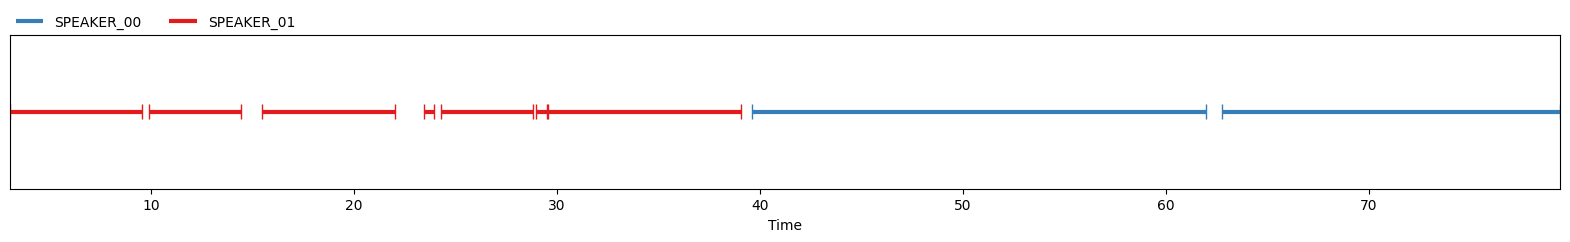

In [ ]:
diarization.speaker_diarization

In [ ]:
segments = []
for turn, speaker in diarization.speaker_diarization:
    segments.append({
        "start": round(turn.start, 2),
        "end": round(turn.end, 2),
        "speaker": speaker
    })

print(segments)

[{'start': 3.05, 'end': 9.55, 'speaker': 'SPEAKER_01'}, {'start': 9.89, 'end': 14.41, 'speaker': 'SPEAKER_01'}, {'start': 15.45, 'end': 22.04, 'speaker': 'SPEAKER_01'}, {'start': 23.45, 'end': 23.96, 'speaker': 'SPEAKER_01'}, {'start': 24.28, 'end': 28.8, 'speaker': 'SPEAKER_01'}, {'start': 28.95, 'end': 29.53, 'speaker': 'SPEAKER_01'}, {'start': 29.58, 'end': 39.05, 'speaker': 'SPEAKER_01'}, {'start': 39.59, 'end': 62.0, 'speaker': 'SPEAKER_00'}, {'start': 62.76, 'end': 79.41, 'speaker': 'SPEAKER_00'}]


## Step 4: Transcribe with Word Timestamps

Whisper converts speech to text. Word timestamps are important because they let us connect each word back to the speaker segment from diarization.


Word timestamps matter because they let us attach the transcript back to pyannote speaker turns. In other words, Whisper tells us **what was said**, and pyannote tells us **where each speaker was active**.



In [ ]:
from faster_whisper import WhisperModel

# Use "tiny" or "base" for quick demos. Use "small" for better quality when you can wait.
whisper = WhisperModel("small")

print( "faster-whisper loaded" )


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.bin:   0%|          | 0.00/484M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

vocabulary.txt: 0.00B [00:00, ?B/s]

faster-whisper loaded


In [ ]:
whisper_segments, info = whisper.transcribe(
    AUDIO_FILE,
    word_timestamps=True,
    vad_filter=True,
)

print(f"✓ Transcription started; detected language: {info.language}")


✓ Transcription started; detected language: en


In [ ]:
words = []

for segment in whisper_segments:
    for word in segment.words or []:
        words.append({
            "start": float(word.start),
            "end": float(word.end),
            "text": word.word.strip(),
        })

print(f"✓ Extracted {len(words)} timestamped words")


✓ Extracted 187 timestamped words


## Step 5: Align Words to Speaker Turns

Now we combine the two model outputs.

Instead of assigning speakers word by word, use pyannote speaker turns as the structure. For each speaker turn, collect the Whisper words that overlap that time range.

This is easier to reason about in a developer demo:

- pyannote owns the speaker timeline
- Whisper owns the words
- overlap decides which words belong inside each speaker turn

What this step proves: diarization + transcription becomes a speaker-labeled transcript without hand-wavy midpoint matching.


In [ ]:
def overlap_seconds(start_a, end_a, start_b, end_b):
    return max(0, min(end_a, end_b) - max(start_a, start_b))


def words_for_segment(segment, words, min_overlap_ratio=0.5):
    segment_words = []

    for word in words:
        word_duration = word["end"] - word["start"]
        if word_duration <= 0:
            continue

        overlap = overlap_seconds(
            segment["start"],
            segment["end"],
            word["start"],
            word["end"],
        )

        if overlap / word_duration >= min_overlap_ratio:
            segment_words.append(word["text"])

    return " ".join(segment_words).strip()


In [ ]:
turns = []

for segment in segments:
    text = words_for_segment(segment, words)

    if text:
        turns.append(
            {
                "speaker": segment["speaker"],
                "start": segment["start"],
                "end": segment["end"],
                "text": text,
            }
        )

print(f"OK Built {len(turns)} speaker-labeled transcript turns")



OK Built 8 speaker-labeled transcript turns


In [ ]:
def mmss(seconds):
    minutes = int(seconds // 60)
    secs = int(seconds % 60)
    return f"{minutes:02d}:{secs:02d}"

for turn in turns[:6]:
    print(f'[{mmss(turn["start"])}] {turn["speaker"]}: {turn["text"]}')


[00:03] SPEAKER_01: me ask you about AI. It seems like this year, for the entirety of the human civilization, is an interesting year
[00:09] SPEAKER_01: the development of artificial intelligence. A lot of interesting stuff is happening.
[00:15] SPEAKER_01: So Meta is a big part of that. Meta has developed Lama, which is a 65 billion parameter model.
[00:24] SPEAKER_01: There's a lot of interesting questions that can ask here, one of which has to do with open source.
[00:28] SPEAKER_01: First,
[00:29] SPEAKER_01: can you tell the story of developing of this model and making the complicated decision of how to release it?


In [ ]:
print(turns)

[{'speaker': 'SPEAKER_01', 'start': 3.05, 'end': 9.55, 'text': 'me ask you about AI. It seems like this year, for the entirety of the human civilization, is an interesting year'}, {'speaker': 'SPEAKER_01', 'start': 9.89, 'end': 14.41, 'text': 'the development of artificial intelligence. A lot of interesting stuff is happening.'}, {'speaker': 'SPEAKER_01', 'start': 15.45, 'end': 22.04, 'text': 'So Meta is a big part of that. Meta has developed Lama, which is a 65 billion parameter model.'}, {'speaker': 'SPEAKER_01', 'start': 24.28, 'end': 28.8, 'text': "There's a lot of interesting questions that can ask here, one of which has to do with open source."}, {'speaker': 'SPEAKER_01', 'start': 28.95, 'end': 29.53, 'text': 'First,'}, {'speaker': 'SPEAKER_01', 'start': 29.58, 'end': 39.05, 'text': 'can you tell the story of developing of this model and making the complicated decision of how to release it?'}, {'speaker': 'SPEAKER_00', 'start': 39.59, 'end': 62.0, 'text': "Yeah, sure. I think you

In [ ]:
import json

with open("transcript.json", "w", encoding="utf-8") as f:
    json.dump(turns, f, indent=2, ensure_ascii=False)

with open("transcript.md", "w", encoding="utf-8") as f:
    for turn in turns:
        line = f'[{mmss(turn["start"])}] {turn["speaker"]}: {turn["text"]}'
        f.write(line + "\n\n")

print("✓ Saved transcript.json and transcript.md")


✓ Saved transcript.json and transcript.md


## Step 6: Reason Over the Conversation With Gemma

Now that pyannote has given us speaker-aware structure, Gemma can do more than summarize.

The model can connect evidence to recommendations:

1. identify the moment where a speaker raised a topic, blocker, or need
2. explain the pain point or opportunity
3. suggest a content idea based on that evidence
4. give the reason why that content would help

This is where pyannote becomes product value. Because every transcript turn has a timestamp and speaker, Gemma can ground its suggestions in specific moments from the conversation instead of producing generic ideas.

In [ ]:
# One-time setup for Gemma through Ollama.
!apt-get update -qq && apt-get install -y -qq zstd
!command -v ollama >/dev/null || curl -fsSL https://ollama.com/install.sh | sh
!nohup ollama serve > /tmp/ollama.log 2>&1 &
!ollama pull gemma3:1b

print("OK Gemma is ready through Ollama")


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package zstd.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.

OK Gemma is ready through Ollama


In [ ]:
import json
import re
import requests

transcript = "\n".join(
    f"[{mmss(turn['start'])}] {turn['speaker']}: {turn['text']}"
    for turn in turns
)[:12000]

prompt = f"""
You are a DevRel strategist analyzing a speaker-labeled community call transcript.

Reason from the transcript. Do not only extract text.
For each recommendation, explain what the speaker said, when they said it, what pain point or opportunity it reveals, and why the suggested content would help.

Return JSON only with this exact shape:
{{
  "summary": "2 concise sentences",
  "moments": [
    {{
      "timestamp": "MM:SS",
      "speaker": "SPEAKER_00",
      "what_they_said": "short evidence from the transcript",
      "insight": "what this reveals"
    }}
  ],
  "pain_points": [
    {{
      "timestamp": "MM:SS",
      "speaker": "SPEAKER_00",
      "pain_point": "the inferred blocker or need",
      "evidence": "what the speaker said",
      "why_it_matters": "why a community or DevRel team should care"
    }}
  ],
  "content_ideas": [
    {{
      "timestamp": "MM:SS",
      "speaker": "SPEAKER_00",
      "idea": "specific content idea",
      "format": "blog | short video | docs | workshop | social post",
      "based_on": "the source moment or pain point",
      "reason": "why this content would help the audience"
    }}
  ],
  "calls_to_action": [
    {{
      "timestamp": "MM:SS",
      "speaker": "SPEAKER_00",
      "action": "recommended next step",
      "reason": "why this action follows from the transcript"
    }}
  ]
}}

Transcript:
{transcript}
"""

response = requests.post(
    "http://localhost:11434/api/chat",
    json={
        "model": "gemma3:1b",
        "messages": [{"role": "user", "content": prompt}],
        "stream": False,
        "format": "json",
        "options": {"temperature": 0},
    },
    timeout=600,
)
response.raise_for_status()

reply = response.json()["message"]["content"]

try:
    insights = json.loads(reply)
except json.JSONDecodeError:
    match = re.search(r"\{.*\}", reply, flags=re.DOTALL)
    if not match:
        print(reply)
        raise
    insights = json.loads(match.group(0))

print(json.dumps(insights, indent=2, ensure_ascii=False))

with open("insights.json", "w", encoding="utf-8") as f:
    json.dump(insights, f, indent=2, ensure_ascii=False)



{
  "summary": "The speaker discusses Meta's development of Lama, a large language model, highlighting the increasing focus on scaling up these models and their open-source approach.",
  "moments": [
    {
      "timestamp": "[00:09]",
      "speaker": "SPEAKER_01",
      "what_they_said": "The speaker introduces the topic of AI development, specifically mentioning Meta's development of Lama and its 65 billion parameter model.",
      "insight": "This establishes a context for the discussion about large language models and their potential impact."
    },
    {
      "timestamp": "[00:15]",
      "speaker": "SPEAKER_01",
      "what_they_said": "The speaker asks about the development of Lama, specifically focusing on the decision-making process regarding its release – how to balance openness and academic research.",
      "insight": "This reveals a key strategic question related to open source AI models."
    },
    {
      "timestamp": "[00:24]",
      "speaker": "SPEAKER_01",
      "w

<!-- precision-2-appendix -->
## Hosted Shortcut: Precision-2 Does Diarization + Transcription

pyannoteAI Precision-2 makes the core audio step much smaller:

> Send audio to Precision-2, request transcription, and receive speaker-labeled transcript turns.

That means pyannoteAI handles the speaker timeline and hosted speech-to-text together. No local Whisper setup. No custom word-to-speaker alignment code. The API returns the structure developers actually want to build on.

Use this section to show the API-native version of the same idea AudioMind uses in the app.


In [ ]:

import json
import os
import time
from getpass import getpass


import requests

url = "https://api.pyannote.ai/v1/diarize"

payload = {
    "url": "https://files.pyannote.ai/marklex1min.wav",
    "model": "precision-2",
    "minSpeakers": 1,
    "maxSpeakers": 4,
    "turnLevelConfidence": False,
    "exclusive": False,
    "confidence": False,
    "transcription": True,
    "transcriptionConfig": { "model": "parakeet-tdt-0.6b-v3" }
}
headers = {
    "Authorization": "Bearer <token>",
    "Content-Type": "application/json"
}

response = requests.post(url, json=payload, headers=headers)

print(response.text)


{"jobId":"798e7d7d-0421-4980-b5ab-ae70e2fb4a38","status":"created"}


In [ ]:

url = "https://api.pyannote.ai/v1/jobs/<jobId"

headers = {"Authorization": "Bearer <token>"}

response = requests.get(url, headers=headers)

print(response.text)

{"jobId":"798e7d7d-0421-4980-b5ab-ae70e2fb4a38","status":"succeeded","createdAt":"2026-06-14T05:29:35.897Z","updatedAt":"2026-06-14T05:29:40.342Z","output":{"diarization":[{"speaker":"SPEAKER_00","start":3.005,"end":5.945},{"speaker":"SPEAKER_00","start":6.345,"end":9.565},{"speaker":"SPEAKER_00","start":9.925,"end":12.065},{"speaker":"SPEAKER_00","start":12.505,"end":14.445},{"speaker":"SPEAKER_00","start":15.505,"end":22.085},{"speaker":"SPEAKER_00","start":23.405,"end":24.005},{"speaker":"SPEAKER_00","start":24.285,"end":29.505},{"speaker":"SPEAKER_00","start":29.705,"end":35.705},{"speaker":"SPEAKER_00","start":36.105,"end":39.045},{"speaker":"SPEAKER_01","start":39.565,"end":40.525},{"speaker":"SPEAKER_01","start":40.705,"end":45.985},{"speaker":"SPEAKER_01","start":46.385,"end":61.725},{"speaker":"SPEAKER_01","start":62.765,"end":64.765},{"speaker":"SPEAKER_01","start":65.545,"end":66.025},{"speaker":"SPEAKER_01","start":66.985,"end":67.905},{"speaker":"SPEAKER_01","start":68.225

## Bonus: Voiceprints From a Local Audio File

The pyannoteAI API cannot read a file path directly from your laptop, because the API runs on pyannoteAI servers.

This one cell handles the voiceprint creation flow:

1. read your API key
2. upload your local speaker sample to pyannoteAI media storage
3. create a voiceprint from that uploaded file

You do **not** need to host the audio on a public URL.

All you need to do is to go to pyannote dashboard and get your API key.


In [ ]:
import mimetypes
import os
import time
import uuid
from getpass import getpass
from pathlib import Path

import requests

API_BASE = "https://api.pyannote.ai/v1"

PYANNOTE_API_KEY = os.getenv("PYANNOTE_API_KEY") or getpass("pyannoteAI API key: ")
HEADERS = {
    "Authorization": f"Bearer {PYANNOTE_API_KEY}",
    "Content-Type": "application/json",
}

print("API client ready")

In [ ]:
import json
import mimetypes
import os
import time
import uuid
from getpass import getpass
from pathlib import Path

import requests


# ------------------------------------------------------------
# 2. Upload a local file to pyannoteAI private media storage
# ------------------------------------------------------------

def get_audio_file(file_path):
    """Return a Path that exists. In Colab, open an upload picker if needed."""
    file_path = Path(file_path).expanduser()

    if file_path.exists():
        return file_path

    try:
        from google.colab import files
    except ImportError:
        print("Current notebook folder:", Path.cwd())
        print("Files here:", [p.name for p in Path.cwd().iterdir() if p.is_file()][:20])
        raise FileNotFoundError(
            f"File not found: {file_path}. Use the full path, or put the file in the current notebook folder."
        )

    print(f"{file_path} was not found in this Colab runtime.")
    print("Choose the audio file from your laptop now.")
    uploaded = files.upload()
    uploaded_name = next(iter(uploaded.keys()))
    return Path(uploaded_name)


def upload_local_audio(file_path):
    """Upload a local audio file and return a pyannoteAI media:// URL."""
    file_path = get_audio_file(file_path)

    media_url = f"media://audiomind/{uuid.uuid4().hex}-{file_path.name}"

    response = requests.post(
        f"{API_BASE}/media/input",
        headers=HEADERS,
        json={"url": media_url},
    )
    response.raise_for_status()
    upload_url = response.json()["url"]

    content_type = mimetypes.guess_type(file_path.name)[0] or "application/octet-stream"
    with file_path.open("rb") as audio_file:
        upload_response = requests.put(
            upload_url,
            data=audio_file,
            headers={"Content-Type": content_type},
        )
    upload_response.raise_for_status()

    return media_url


# ------------------------------------------------------------
# 3. Wait for async pyannoteAI jobs
# ------------------------------------------------------------

def wait_for_job(job_id, poll_seconds=3):
    """Poll a pyannoteAI job until it finishes."""
    while True:
        response = requests.get(
            f"{API_BASE}/jobs/{job_id}",
            headers={"Authorization": f"Bearer {PYANNOTE_API_KEY}"},
        )
        response.raise_for_status()
        job = response.json()

        if job["status"] == "succeeded":
            return job
        if job["status"] in {"failed", "canceled"}:
            raise RuntimeError(job)

        print("Waiting for job:", job["status"])
        time.sleep(poll_seconds)


# ------------------------------------------------------------
# 4. Create a voiceprint from a local single-speaker sample
# ------------------------------------------------------------

def create_voiceprint(local_sample_file):
    sample_url = upload_local_audio(local_sample_file)
    print("Uploaded voice sample:", sample_url)

    response = requests.post(
        f"{API_BASE}/voiceprint",
        headers=HEADERS,
        json={"url": sample_url, "model": "precision-2"},
    )
    response.raise_for_status()

    job = wait_for_job(response.json()["jobId"])
    return job["output"]["voiceprint"]


# ------------------------------------------------------------
# 5. Run this for your local speaker sample
# ------------------------------------------------------------

VOICE_SAMPLE_FILE = "New_Recording.wav"

voiceprint = create_voiceprint(VOICE_SAMPLE_FILE)
print("Voiceprint created. Length:", len(voiceprint))


# ------------------------------------------------------------
# 6. Optional: identify that known voice in a longer local call
# ------------------------------------------------------------

def identify_voice_in_local_call(local_call_file, speaker_name, voiceprint):
    call_url = upload_local_audio(local_call_file)
    print("Uploaded call audio:", call_url)

    response = requests.post(
        f"{API_BASE}/identify",
        headers=HEADERS,
        json={
            "url": call_url,
            "model": "precision-2",
            "voiceprints": [
                {"label": speaker_name, "voiceprint": voiceprint}
            ],
            "matching": {"exclusive": True, "threshold": 0},
        },
    )
    response.raise_for_status()

    return wait_for_job(response.json()["jobId"])



## Identification Job: Find That Voice in a Local Call

Now that the previous cell created a `voiceprint`, this cell uploads a longer local call and submits an identification job.


In [ ]:
import requests

url = "https://api.pyannote.ai/v1/identify"

payload = {
    "voiceprints": [
        {
            "label": "John Doe",
            "voiceprint": "voiceprint"
        }
    ],
    "url": "<ORIGINAL AUDIO FILE>",
    "model": "precision-2",
    "numSpeakers": 2,
    "turnLevelConfidence": False,
    "exclusive": False,
    "confidence": False,
    "matching": {
        "exclusive": True,
        "threshold": 0
    }
}
headers = {
    "Authorization": "Bearer {PYANNOTE_API_KEY}",
    "Content-Type": "application/json"
}

response = requests.post(url, json=payload, headers=headers)

print(response.text)